## Assignment 6 Instructions: Document Classification

It can be useful to be able to classify new "test" documents using already classified "training" documents.  A common example is using a corpus of labeled spam and ham (non-spam) e-mails to predict whether or not a new document is spam.  Here is one example of such data:  UCI Machine Learning Repository: Spambase Data Set

For this project, you can either use the above dataset to predict the class of new documents (either withheld from the training dataset or from another source such as your own spam folder).

For more adventurous students, you are welcome (encouraged!) to come up a different set of documents (including scraped web pages!?) that have already been classified (e.g. tagged), then analyze these documents to predict how new documents should be classified.

### Executive Summary Draft

This project builds a document classification model to distinguish between spam and non-spam emails using the **(UCI Spambase dataset)[https://archive.ics.uci.edu/dataset/94/spambase]**. Following techniques from the NLTK book, and modified using the scikit-learn machine learning library,I preprocess text-like features, train a classifier (Naive Bayes), and evaluate its performance using common classification metrics.

The model successfully learned patterns associated with spam emails and achieved an overall accuracy of 82% on unseen test data. It demonstrated strong recall performance in detecting spam (0.95), correctly identifying 369 out of 390 spam emails, indicating a low rate of missed spam. However, the model had a lower precision for spam classification (0.72), incorrectly classifying 143 legitimate emails as spam (false positives). The model also achieved an ROC-AUC score of 0.94, indicating a very good overall ability to distinguish between spam and non-spam across different decision thresholds.

Attempts to improve performance by adjusting the classification threshold from 0.5 to .70 had minimal impact, suggesting that the observed false positive rate is driven more by model limitations than decision boundary settings. Overall, the model performs well at identifying spam but tends to aggressively classify emails as spam.

#### Module 1: Download spam dataset directly from the UCI Online Repository

The UCI collection of spam e-mails came from their postmaster and individuals who had filed spam.  Their collection of non-spam e-mails came from filed work and personal e-mails, and hence the word 'george' and the area code '650' are indicators of non-spam. Per the authors of the dataset, typical performance is around ~7% misclassification error. False positives (marking good mail as spam) are very undesirable. If zero false positives are required in the training/testing set, 20-25% of the spam passed through the filter. The authors note that there are missing values in the dataset, which I will need to address.

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
print(spambase.metadata) 
  
# variable information 
print(spambase.variables) 


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

#### Module 2: Combine Labels and Inspect the Spambase Data

In this module, I combined the categories and the labels into one dataframe and inspected the dataframe.

In [2]:
import pandas as pd

# Combine X and y into one DataFrame
y.columns = ["label"]
df = pd.concat([X, y], axis=1)
# df.to_csv("spambase.csv", index=False)

In [4]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,label
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


#### Module 3: Look for Missing Values

In the dataset information, the authors noted that it contains missing values. Although the authors state that the dataset contains missing values, I see none.

In [5]:
# Check total missing values in each column
missing_per_column = X.isnull().sum()

print(missing_per_column)

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

#### Module 4: Check for Class Imbalance

In this module, to prevent a biased classifier, I checked for class imbalance to make sure that I have appropriate representation between spam and nonspam emails. The classes are slightly imbalanced, but still acceptable without further treatment for modeling.

In [6]:
# Percentage in each class
class_percent = (y.value_counts(normalize=True) * 100).round(2)

print(class_percent)

label
0        60.6
1        39.4
Name: proportion, dtype: float64


#### Module 5: Split into Training and Test Sets

Per Chapter 6 in Bird et al. (2009), the nltk library classifier is not designed for dataframes. To use it, classification has to be in the form of a feature set, label pairing.  The spambase data is currently in a pandas dataframe, and the nltk classifier does not work well with it. The more direct way to create a workflow is to use the scikit-learn library, which accepts a pandas dataframe. 

At this stage, given that the spambase dataset is already in numeric form, there are no missing values, they are all int64 datatypes, and the classes are fairly balanced, I divided the dataset into training and testing sets.


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y.values.ravel(), test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 3680
Test size: 921


#### Module 6: Train Naive Bayes Classifier

This code sets up and trains a spam detection model. From the scikit-learn library, I am pulling out the Naive Bayes model designed for numeric data. GaussianNB is a specific classifier used when the data consists of numerical values.

The "model" object creates an empty model ready to learn something. The model.fit(X_train, y_train) populates the model with which patterns, such as word frequencies or symbols from the training data, are associated with spam versus normal emails. After this step, the model is ready to make predictions on unseen emails.

In [8]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


#### Module 7: Make Predictions

The 'from sklearn.metrics import accuracy_score, classification_report' line imports tools to measure how well the model is performing.

The y_pred = model.predict(X_test) line uses the trained model to make predictions on unseen data.

The predict() function takes the test data and predicts whether each email is spam, and accuracy_score and classification_report compare those predictions to the actual labels. It also shows how accurate the model by measuring precision, recall, f1-score, and support to figure out where the model might be making mistakes. The accuracy_score informs us how often the model is correct. The precision score informs us how accurate spam predictions are. The recall score informs us how much spam is caught. The F1 score informs us of the balance between precision and recall.

The model achieves 82% accuracy, correctly identifying most emails overall. It is strong at catching spam with 95% recall, but has lower precision at 72% for spam, meaning some legitimate emails are incorrectly classified as spam.

In [9]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.73      0.82       531
           1       0.72      0.95      0.82       390

    accuracy                           0.82       921
   macro avg       0.83      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921



#### Module 8: Create and Plot a Confusion Matrix

The module analyzes a confusion matrix. Out of 921 emails, the model correctly identified 387 non-spam and 369 spam emails, but incorrectly labeled 144 legitimate emails as spam (false positives) and missed only 21 spam emails (false negatives). This shows that the model is a strong spam detector but over labels normal emails as spam.

[[387 144]
 [ 21 369]]


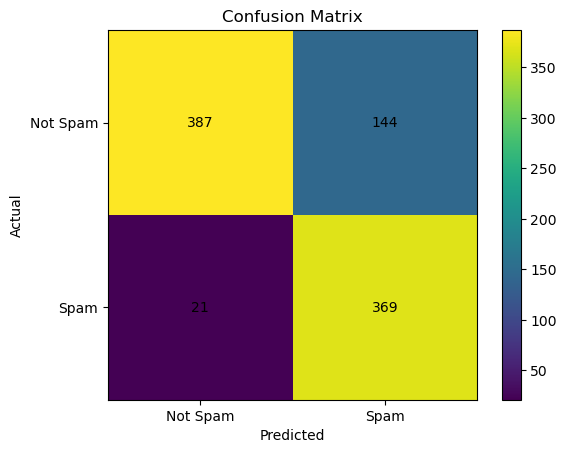

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0,1], ["Not Spam", "Spam"])
plt.yticks([0,1], ["Not Spam", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

#### Module 9: ROC Curve

The model achieves an AUC score of 0.94, indicating a very good ability to distinguish between spam and non-spam across all thresholds, demonstrating strong overall classification capability.

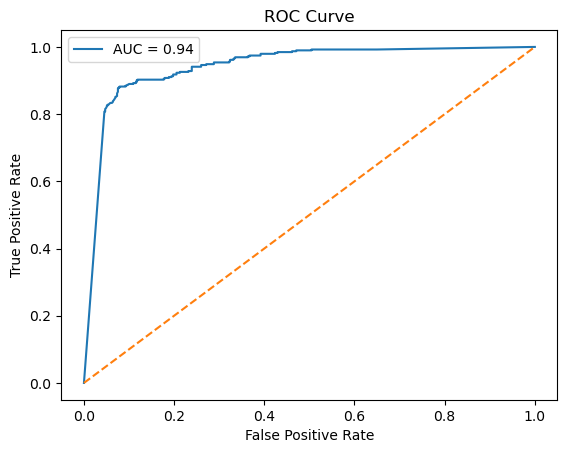

In [11]:
y_prob = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

#### Module 10: Adjustments to Improve False Positives

Since the false positive figure was high, I tried increasing the threshold from .05 to 0.7 and reran the model. However, it resulted in no meaningful change in performance. The accuracy level still remained at 0.82, with 389 non-spam and 369 spam emails correctly classified, 142 false positives, and 21 false negatives. Increasing the threshold only improved false positives by 2 emails. This may indicate that a false positive problem may be inherent to the model rather than the decision threshold. However, the model is very strong at detecting spam, as the recall rate is still 0.95.

In [12]:
# Adjust threshold to reduce false positives

y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.7
y_pred_adjusted = (y_prob > threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy:", round(accuracy_score(y_test, y_pred_adjusted), 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_adjusted))

cm = confusion_matrix(y_test, y_pred_adjusted)
print("\nConfusion Matrix:\n", cm)

Threshold: 0.7
Accuracy: 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.73      0.83       531
           1       0.72      0.95      0.82       390

    accuracy                           0.82       921
   macro avg       0.84      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921


Confusion Matrix:
 [[389 142]
 [ 21 369]]
